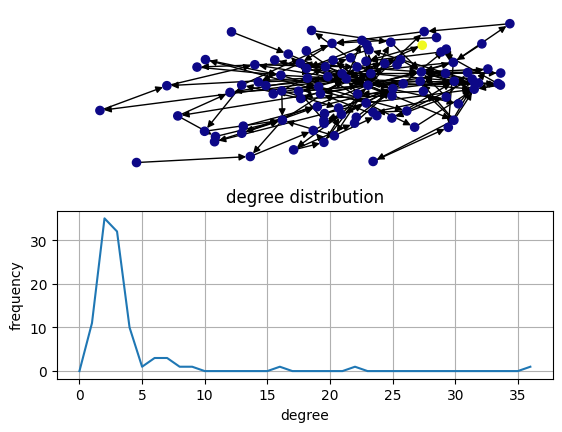

In [99]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random as random

class SocialNetwork():
    def weight_Amatrix_Poisson(self,Amatrix):
        for i,node in enumerate(Amatrix):

            neighbors = np.where(node == 1)[0]
            weights = np.zeros(self.n)

            poisson_vals = np.random.poisson(self.k, len(neighbors))
            weights[neighbors] = poisson_vals

            if weights.sum() == 0:
                continue

            Amatrix[i] = weights / weights.sum()
        return Amatrix

    def __init__(self, n=100, k=1):
        self.n=n
        self.k=k

        Insample = nx.barabasi_albert_graph(n, k)        
        InAmatrix = self.weight_Amatrix_Poisson(np.triu(nx.to_numpy_array(Insample)))
        
        Outsample = nx.barabasi_albert_graph(n, k)        
        OutAmatrix = self.weight_Amatrix_Poisson(np.tril(nx.to_numpy_array(Outsample)))

        SampleAmatrix = InAmatrix + OutAmatrix
        
        self.G = nx.from_numpy_array(SampleAmatrix,create_using=nx.DiGraph)
        for id in self.G.nodes:
            self.G.nodes[id]["state"] = 0
            self.G.nodes[id]["immunity"] = 0
            self.G.nodes[id]["transition time"] = 0

    def show(self):
        _, axs = plt.subplots(2)

        layout = nx.spring_layout(self.G)
        nx.draw(self.G, pos=layout,ax=axs[0], node_size=35, node_color=[self.G.nodes[i]['state'] for i in self.G.nodes],cmap=plt.cm.plasma)
        degree_dist = nx.degree_histogram(self.G)
        axs[1].plot([i for i,_ in enumerate(degree_dist)], degree_dist)
        axs[1].set_title("degree distribution")
        axs[1].set_xlabel("degree")
        axs[1].set_ylabel("frequency")
        axs[1].grid(True)
        plt.show()

    def show_degree_centrality(self):
        centrality = nx.degree_centrality(self.G)
        plt.grid(True)
        plt.title("degree centrality")
        plt.xlabel("node")
        plt.ylabel("centrality")
        plt.plot(centrality.keys(),centrality.values())
        plt.show()

class ZombieApocolypse():
    def __init__(self,initial_infected_num=1,n=100):
        self.network = SocialNetwork(n)
        initial_infected = random.sample(range(self.network.n), initial_infected_num)

        for node in initial_infected:
            self.network.G.nodes[node]["state"] = 1

    def show_state(self):
        self.network.show()

Z = ZombieApocolypse()
Z.show_state()